# NLP Project 2
**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents
1. [Setup & Imports](#setup)
3. [Load & Merge Data](#load)
4. [Exploratory Data Analysis](#eda)
   - 4.1 [Rating Distribution](#rating)
   - 4.2 [Reviews per Insurer](#insurer)
   - 4.3 [Reviews per Product Type](#product)
   - 4.4 [Average Rating per Insurer](#avg_rating)
5. [Frequent Words & N-grams](#ngrams)
6. [Data Cleaning](#cleaning)
7. [Visualization](#visualization)
8.
8. [Conclusion](#conclusion)

📋 Project Roadmap (in recommended order)
- Step 1 — Data Cleaning & EDA
-       Load all 35 files, merge, visualize distributions, find frequent words/n-grams, and do spelling correction to fill avis_cor
- Step 2 — Summary, Translation & Generation
-       Use a model (e.g. HuggingFace) to produce clean summaries and populate avis_cor_en
- Step 3 — Topic Modeling
-       LDA or BERTopic to find themes in reviews (pricing, service, claims, etc.)
- Step 4 — Embeddings
-       Train Word2Vec, use GloVe, visualize with Matplotlib/TensorBoard, implement semantic search
- Step 5 — Supervised Learning (star rating prediction)
-       TF-IDF + classical ML → Basic embedding model → Pre-trained embeddings → BERT/USE/LLM
- Step 6 — Streamlit Apps
-       Prediction app + Insurer analysis dashboard

In [3]:
#TODO:
# - Afficher le nombre de fichiers excel dans le dossier data
# - Afficher le nombre de lignes et de colonnes de chaque dataset
# - Afficher la shape, data types, nombre de valeurs uniques, de valeurs manquantes de chaque dataset, nombre de dupliqués

## 0. Dependencies

In [6]:
# !pip install pandas openpyxl matplotlib seaborn wordcloud textblob deep-translator tqdm nlpclean

## 1. Setup & Imports

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import preprocessing as ppr

## 2. Load & Merge Data

The dataset consists of 35 Excel files, each containing reviews for an insurance product. We will load all these files, merge them into a single DataFrame, and perform an initial exploration to understand the structure and content of the data.

The dataset contains the following columns:

| Column | Description                                         |
| :--- |:----------------------------------------------------|
| `note` | Star rating 1–5 (main prediction target)            |
| `avis` | Original review in French                           |
| `avis_en` | Automatic translation of the review to English      |
| `avis_cor` | Corrected French review                             |
| `avis_cor_en` | Corrected and translated English review             |
| `assureur` | Insurance company name                              |
| `produit` | Insurance product type (auto, santé, animaux, etc.) |
| `date_publication` | Review date                                         |

In [18]:
CURRENT_DIR = Path.cwd()
DATA_DIR = CURRENT_DIR / "data"

def read_dataset(n:int=35) -> list[pd.DataFrame]:
    dataset_list = []
    for i in range(1, n + 1):
        try:
            file_name = f"avis_{i}_traduit.xlsx"
            dataset_list.append(pd.read_excel(DATA_PATH / file_name, engine="openpyxl"))
        except Exception as e:
            print(f"Error when reading the {file_name} ->{e}")
    return dataset_list

def fusion_dataset(dataset_list: list[pd.DataFrame])-> pd.DataFrame:
    try:
        df_final = pd.concat(dataset_list, ignore_index=True)
        return df_final
    except Exception as e:
        print(f"Error  : {e}")
        return pd.DataFrame()

In [31]:
print(f"Found {len(dataset_list)} Excel files")

Found 35 Excel files


In [30]:
dataset_list= read_dataset()
df = fusion_dataset(dataset_list)
df

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
34430,NaN,mamybouly-129360,"Bonjour, j'ai une mauvaise expérience avec la ...",Sma,garantie-decennale,test,24/08/2021,01/08/2021,"Hello, I have a bad experience with the Socoba...","Bonjour, j'ai une mauvaise expérience avec la ...","Hello, I have a bad experience with the Socoba..."
34431,NaN,tarti-88637,Entreprise très impactée par le covid- secteur...,Allianz,assurances-professionnelles,test,18/05/2021,01/05/2021,Company very impacted by the covid- event sect...,Entreprise très impactée par le covid- secteur...,NaN
34432,NaN,victor-109599,"Suite a un cambriolage le 22/01/2021, je suis ...",Allianz,assurances-professionnelles,test,08/04/2021,01/04/2021,"Following a burglary on 01/22/2021, I am still...","Suite a un cambriolage le 22/01/2021, je suis ...",NaN
34433,NaN,lkio-110907,"Bonjour,\n\nJe constate qu'entre le moment de ...",Generali,assurances-professionnelles,test,19/04/2021,01/04/2021,"Hello,\n\nI note that between the time of my r...","Bonjour,\n\nJe constate qu'entre le moment de ...",NaN


In [32]:
# Basic info
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (34435, 11)

Dtypes:
 note                float64
auteur                  str
avis                    str
assureur                str
produit                 str
type                    str
date_publication        str
date_exp                str
avis_en                 str
avis_cor             object
avis_cor_en          object
dtype: object

Missing values:
 note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

Duplicate rows: 5


In [21]:
WHITELIST = ""
def spelling_correction(text: str) -> str:
    # 1. Minuscules & Nettoyage ponctuation
    # 2. Correction orthographique (ex: 'assurence' -> 'assurance')
    # 3. Retrait des stopwords (ex: 'le', 'un')
    clean_text = ""
    return clean_text

## 3. Exploratory Data Analysis

### 3.1 Rating Distribution

In [33]:
note_counts = df["note"].value_counts().sort_index()
note_counts

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64

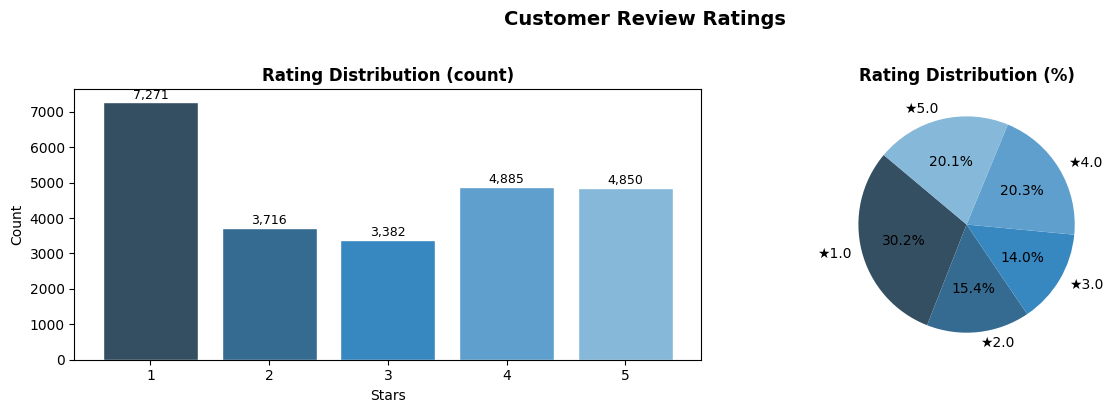

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
bars = axes[0].bar(note_counts.index, note_counts.values,
                   color=sns.color_palette("Blues_d", 5)[::-1], edgecolor="white")
axes[0].set_title("Rating Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, f"{bar.get_height():,}",
                 ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(note_counts.values, labels=[f"★{i}" for i in note_counts.index],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Blues_d", 5)[::-1])
axes[1].set_title("Rating Distribution (%)", fontweight="bold")

plt.suptitle("Customer Review Ratings", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("rating_distribution.png", bbox_inches="tight")
plt.show()

### 3.2 Reviews per Insurer

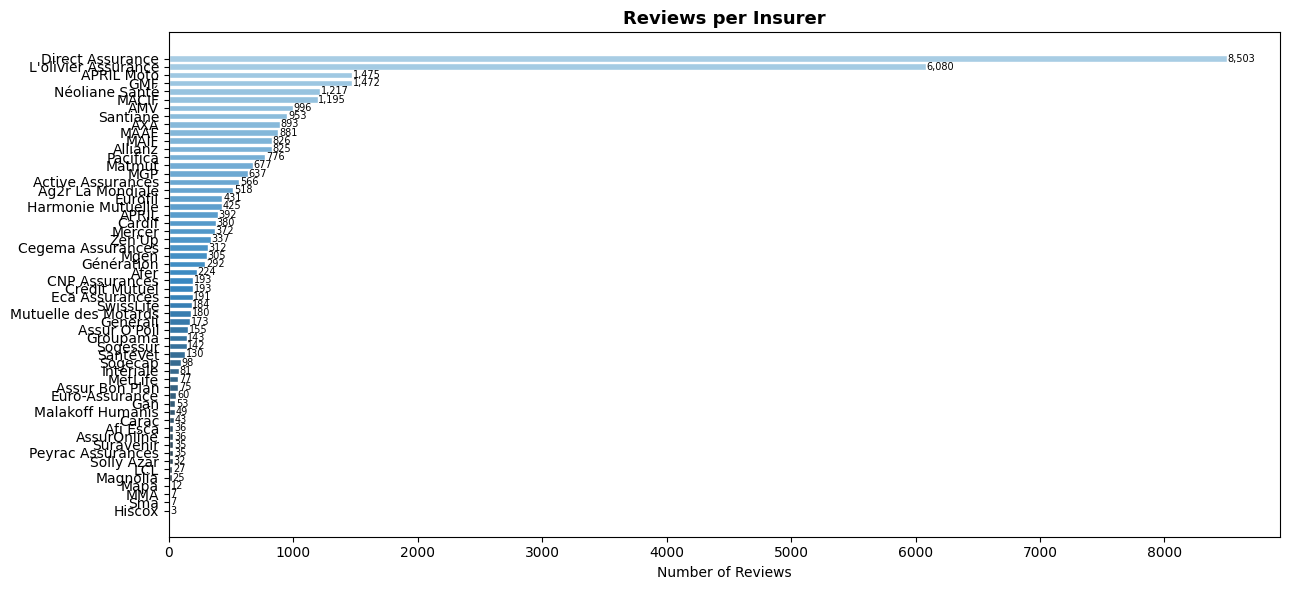

In [37]:
insurer_counts = df["assureur"].value_counts()

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Blues_d", len(insurer_counts))
bars = ax.barh(insurer_counts.index, insurer_counts.values,
               color=colors, edgecolor="white")
ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Insurer", fontweight="bold", fontsize=13)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("reviews_per_insurer.png", bbox_inches="tight")
plt.show()

### 3.3 Reviews per Product Type

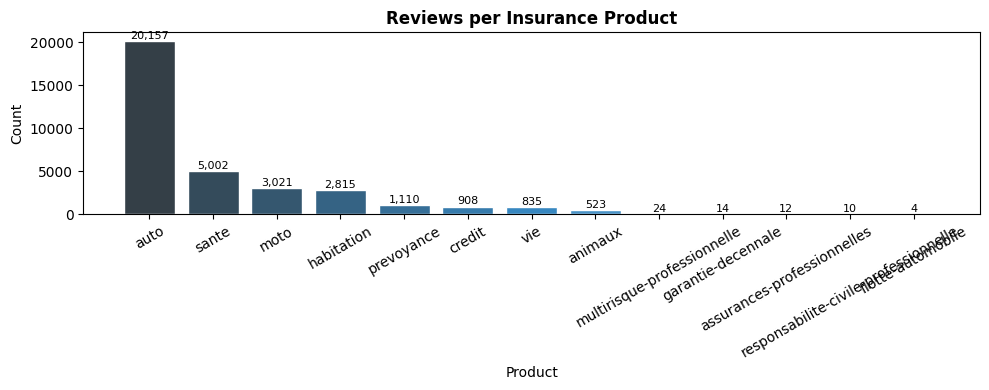

In [38]:
prod_counts = df["produit"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(prod_counts.index, prod_counts.values,
              color=sns.color_palette("Blues_d", len(prod_counts))[::-1],
              edgecolor="white")
ax.set_xlabel("Product"); ax.set_ylabel("Count")
ax.set_title("Reviews per Insurance Product", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30, f"{bar.get_height():,}",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("reviews_per_product.png", bbox_inches="tight")
plt.show()

### 3.4 Average Rating per Insurer (top 20)

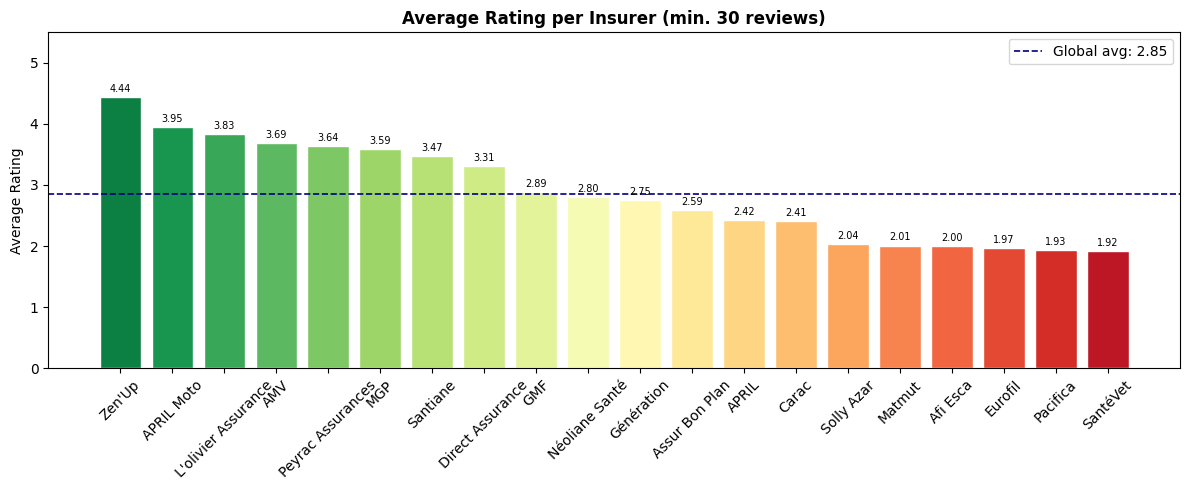

In [39]:
# Only insurers with at least 30 reviews for reliability
insurer_stats = (
    df.groupby("assureur")
    .agg(avg_note=("note", "mean"), count=("note", "size"))
    .query("count >= 30")
    .sort_values("avg_note", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("RdYlGn", len(insurer_stats))
bar_colors = [palette[i] for i in (insurer_stats["avg_note"].rank(method="first").astype(int)-1)]
bars = ax.bar(insurer_stats["assureur"], insurer_stats["avg_note"],
              color=bar_colors, edgecolor="white")
ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1.2, label=f"Global avg: {df['note'].mean():.2f}")
ax.set_ylabel("Average Rating"); ax.set_ylim(0, 5.5)
ax.set_title("Average Rating per Insurer (min. 30 reviews)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig("avg_rating_insurer.png", bbox_inches="tight")
plt.show()

## 4. Frequent Words & N-grams

## 5. Data Cleaning

With pandas, we need to have openpyxl installed to read an .xlsx file

In [3]:
df = ppr.fusion_dataset(dataset_list)
print(f"Shape: {df.shape}")
display(df.describe(include='all').loc[['count', 'unique']])

Shape: (34435, 11)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
count,24104.0,34434,34435,34435,34435,34435,34435,34435,34433,435,431
unique,NaN,33569,34377,56,13,2,1815,61,33264,435,431


In [8]:
print(f"            Train dataset")
print(f"Number of review : {len(df[df["type"]=="train"])}\n")
print(f"Average of star : {df[df["type"]=="train"]["note"].mean()}\n")
print(f"Number of non-empty review : \n{df[df["type"]=="train"].count()}\n")


print(f"            Test dataset")
print(f"Number of review : {len(df[df["type"]=="test"])}")
print(f"Average of star : {df[df["type"]=="test"]["note"].mean()}\n")
print(f"Number of non-empty review : \n{df[df["type"]=="test"].count()}\n")

            Train dataset
Number of review : 24104

Average of star : 2.8476186525058083

Number of non-empty review : 
note                24104
auteur              24103
avis                24104
assureur            24104
produit             24104
type                24104
date_publication    24104
date_exp            24104
avis_en             24103
avis_cor                0
avis_cor_en             0
dtype: int64

            Test dataset
Number of review : 10331
Average of star : nan

Number of non-empty review : 
note                    0
auteur              10331
avis                10331
assureur            10331
produit             10331
type                10331
date_publication    10331
date_exp            10331
avis_en             10330
avis_cor              435
avis_cor_en           431
dtype: int64



In [15]:
print(f"Train : Number of review per {df[df["type"]=="train"]['assureur'].value_counts()}\n")
print(f"Test : Number of review per {df[df["type"]=="test"]['assureur'].value_counts()}\n")

Train : Number of review per assureur
Direct Assurance        5896
L'olivier Assurance     4288
APRIL Moto              1023
GMF                      997
Néoliane Santé           861
MACIF                    829
AMV                      688
Santiane                 658
AXA                      629
MAAF                     612
MAIF                     591
Allianz                  574
Pacifica                 553
Matmut                   474
MGP                      446
Active Assurances        403
Ag2r La Mondiale         350
Harmonie Mutuelle        312
Eurofil                  289
APRIL                    283
Mercer                   267
Cardif                   265
Zen'Up                   245
Cegema Assurances        214
Génération               212
Mgen                     209
CNP Assurances           147
Crédit Mutuel            146
Afer                     144
SwissLife                138
Eca Assurances           132
Mutuelle des Motards     128
Generali                 128
Assur

In [ ]:
print(f"Train : number of review per {df[df["type"]=="train"]['produit'].value_counts()}\n")
print(f"Test : number of review per {df[df["type"]=="test"]['produit'].value_counts()}\n")

Train : number of review per produit
auto                                     14076
sante                                     3525
moto                                      2105
habitation                                1956
prevoyance                                 791
credit                                     653
vie                                        578
animaux                                    374
multirisque-professionnelle                 20
garantie-decennale                          12
assurances-professionnelles                  8
responsabilite-civile-professionnelle        5
flotte-automobile                            1
Name: count, dtype: int64



### Data Cleaning

In [19]:
df[df["type"]=="train"].head(10)

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN
5,1.0,spam-62064,"Vente forcée par téléphone, prétextant des évè...",Néoliane Santé,sante,train,06/03/2018,01/03/2018,"Forced sale by phone, claiming serious events ...",NaN,NaN
6,3.0,ludovic-b-135966,Nouveau client satisfait du prix et des servic...,APRIL,sante,train,05/10/2021,01/10/2021,New customer satisfied with the price and serv...,NaN,NaN
7,1.0,laetitia741-97523,Un assureur m'a contacté par telephone pour me...,SantéVet,animaux,train,17/09/2020,01/09/2020,An insurer contacted me by phone to sell me th...,NaN,NaN
8,1.0,gbernard10-102485,Je ne peux que rejoindre les nombreux avis nég...,Mercer,sante,train,12/01/2021,01/01/2021,I can only join the many negative opinions. I ...,NaN,NaN
9,1.0,rezo31-62544,GENERALI ASSURANCES VIE PATRIMOINE Très mauvai...,Generali,vie,train,21/03/2018,01/03/2018,Generali Insurance life heritage very bad cust...,NaN,NaN


### Visualization

### Conclusion

My conclusion

# Next